# Logistic Regression with K-Fold Cross Validation on MNIST (Digits 0 & 1)

This notebook demonstrates how to implement logistic regression from scratch using only digits 0 and 1 from the MNIST dataset. We use 10-fold cross-validation to evaluate the model for different learning rates. The MNIST dataset is loaded using `torchvision.datasets.MNIST`.

Each step is explained in detail, and code cells are preceded by markdown cells describing their purpose.

## Importing Required Libraries

We import PyTorch, torchvision for loading the MNIST dataset, numpy for numerical operations, and matplotlib for visualization.

## Importing libraries

In [1]:
import torch
from torchvision.datasets import MNIST
from torchvision import transforms
from torch.utils.data import DataLoader, Subset
import numpy as np
import matplotlib.pyplot as plt

## Load the MNIST Dataset (Digits 0 and 1 Only)

We load the MNIST dataset using torchvision, filter for digits 0 and 1, and convert the data to numpy arrays for further processing.

1. Load MNIST dataset.

In [2]:
# Download and load MNIST dataset (train and test)
transform = transforms.Compose([transforms.ToTensor()])
mnist_train = MNIST(root='./data', train=True, download=True, transform=transform)
mnist_test = MNIST(root='./data', train=False, download=True, transform=transform)

# Filter for digits 0 and 1 only
def filter_digits(dataset, digits=[0, 1]):
    indices = [i for i, (_, label) in enumerate(dataset) if label in digits]
    return Subset(dataset, indices)

train_subset = filter_digits(mnist_train, [0, 1])
test_subset = filter_digits(mnist_test, [0, 1])

# Convert to numpy arrays
def subset_to_numpy(subset):
    images = []
    labels = []
    for img, label in DataLoader(subset, batch_size=1):
        images.append(img.squeeze(0).numpy())
        labels.append(label.item())
    return np.array(images), np.array(labels)

X_train, y_train = subset_to_numpy(train_subset)
X_test, y_test = subset_to_numpy(test_subset)

print(f'X_train shape: {X_train.shape}')
print(f'y_train shape: {y_train.shape}')
print(f'X_test shape: {X_test.shape}')
print(f'y_test shape: {y_test.shape}')

X_train shape: (12665, 1, 28, 28)
y_train shape: (12665,)
X_test shape: (2115, 1, 28, 28)
y_test shape: (2115,)


## Visualize Sample Images

Let's visualize a few sample images from the filtered dataset to confirm we have only digits 0 and 1.

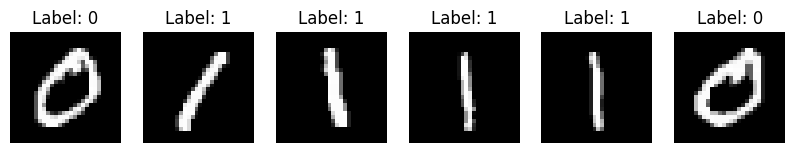

In [5]:
# Plot a few sample images with their labels
num_samples = 6
plt.figure(figsize=(10, 2))
for i in range(num_samples):
    plt.subplot(1, num_samples, i + 1)
    plt.imshow(X_train[i].squeeze(), cmap='gray')
    plt.title(f'Label: {y_train[i]}')
    plt.axis('off')
plt.show()

## Standardize and Reshape the Dataset

We standardize the pixel values (zero mean, unit variance) and flatten each image into a vector, as logistic regression expects 2D input (samples, features).

2. Subset your data to use only class 0 and class1 for the next steps.

In [7]:
Train_indx = np.array([])
Test_indx =np.array([])

for i in range(len(y_train)-1):
    if(y_train[i]==0 or y_train[i]==1):
        Train_indx = np.append(Train_indx, i )

for i in range(len(y_test)-1):
    if(y_test[i]==0 or y_test[i]==1):
        Test_indx = np.append(Test_indx, i )

Train_indx = Train_indx.astype(int)
Test_indx = Test_indx.astype(int)

X_train = X_train[Train_indx]
X_test = X_test[Test_indx]
Y_train = y_train[Train_indx]
Y_test = y_test[Test_indx]


3. Standardize your dataset

In [8]:
# Flatten images to vectors
X_train_flat = X_train.reshape(X_train.shape[0], -1)
X_test_flat = X_test.reshape(X_test.shape[0], -1)

# Standardize features (zero mean, unit variance) using training set statistics
mean = np.mean(X_train_flat, axis=0)
std = np.std(X_train_flat, axis=0)
std[std == 0] = 1e-9  # Prevent division by zero

X_train_std = (X_train_flat - mean) / std
X_test_std = (X_test_flat - mean) / std  # Use train mean/std for test set

# Combine train and test for cross-validation
X_all = np.concatenate([X_train_std, X_test_std], axis=0)
y_all = np.concatenate([y_train, y_test], axis=0)

## K-Fold Cross-Validation Split

We implement a function to split the dataset into k folds for cross-validation. Each fold will be used once as a validation set while the remaining folds form the training set.

4. Divide data into training and validation set using 10-fold cross validation method

In [9]:
def split_k_folds(X, y, k):
    num_samples = len(X)
    fold_size = num_samples // k
    indices = np.random.permutation(num_samples)
    X_folds = []
    y_folds = []
    for i in range(k):
        start = i * fold_size
        end = (i + 1) * fold_size if i < k - 1 else num_samples
        fold_idx = indices[start:end]
        X_folds.append(X[fold_idx])
        y_folds.append(y[fold_idx])
    return X_folds, y_folds

def run_k_fold_cv(X, y, k, model_class, **model_kwargs):
    X_folds, y_folds = split_k_folds(X, y, k)
    scores = []
    for i in range(k):
        X_train = np.concatenate([X_folds[j] for j in range(k) if j != i])
        y_train = np.concatenate([y_folds[j] for j in range(k) if j != i])
        X_val = X_folds[i]
        y_val = y_folds[i]
        model = model_class(**model_kwargs)
        model.fit(X_train, y_train)
        y_pred = model.predict(X_val)
        score = model.f1_score(y_val, y_pred)
        scores.append(score)
    return np.mean(scores)

## Logistic Regression Implementation

We implement a simple logistic regression classifier from scratch, including methods for fitting the model, making predictions, and calculating the F1 score.

5. Implement Logistic Regression with different values for learning rate

In [10]:
class LogisticRegressionScratch:
    """Logistic Regression classifier implemented from scratch."""
    def __init__(self, learning_rate=0.01, num_iterations=1000):
        self.learning_rate = learning_rate
        self.num_iterations = num_iterations

    def fit(self, X, y):
        """Train the model using gradient descent."""
        self.num_samples, self.num_features = X.shape
        self.weights = np.zeros(self.num_features)
        self.bias = 0
        for _ in range(self.num_iterations):
            self._update_weights(X, y)

    def _update_weights(self, X, y):
        linear_model = np.dot(X, self.weights) + self.bias
        y_pred = 1 / (1 + np.exp(-linear_model))
        dw = (1 / self.num_samples) * np.dot(X.T, (y_pred - y))
        db = (1 / self.num_samples) * np.sum(y_pred - y)
        self.weights -= self.learning_rate * dw
        self.bias -= self.learning_rate * db

    def predict(self, X):
        """Predict binary labels for input data."""
        linear_model = np.dot(X, self.weights) + self.bias
        y_pred = 1 / (1 + np.exp(-linear_model))
        return (y_pred > 0.5).astype(int)

    def f1_score(self, y_true, y_pred):
        """Compute the F1 score for binary classification."""
        tp = np.sum((y_true == 1) & (y_pred == 1))
        fp = np.sum((y_true == 0) & (y_pred == 1))
        fn = np.sum((y_true == 1) & (y_pred == 0))
        if tp + fp == 0 or tp + fn == 0:
            return 0.0
        precision = tp / (tp + fp)
        recall = tp / (tp + fn)
        if precision + recall == 0:
            return 0.0
        return 2 * (precision * recall) / (precision + recall)

## Evaluate Model with Different Learning Rates

We run 10-fold cross-validation for several learning rates and report the average F1 score for each. This helps us understand the effect of the learning rate on model performance.

6. Report difference accuracy for the different learning rate.

In [ ]:
learning_rates = [1, 0.1, 0.01, 0.001, 0.0001]
num_folds = 10
num_iterations = 1000

for lr in learning_rates:
    avg_f1 = run_k_fold_cv(
        X_all, y_all, num_folds,
        LogisticRegressionScratch, learning_rate=lr, num_iterations=num_iterations
    )
    print(f"Average F1 score with learning rate {lr}: {avg_f1:.4f}")